2025-12-09 14:17:01.516 
  command:

    streamlit run C:\Users\hafsa\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-12-09 14:17:01.530 Session state does not function when running a script without `streamlit run`


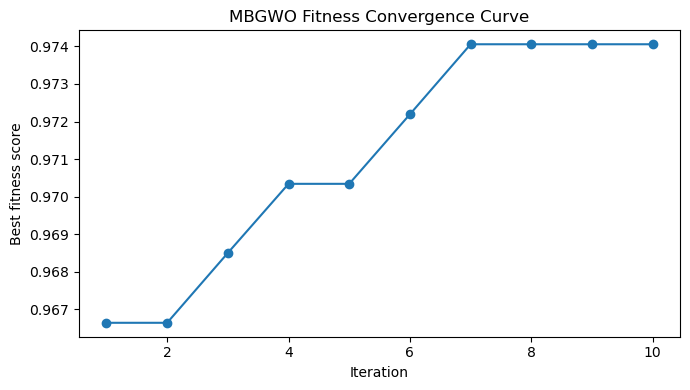

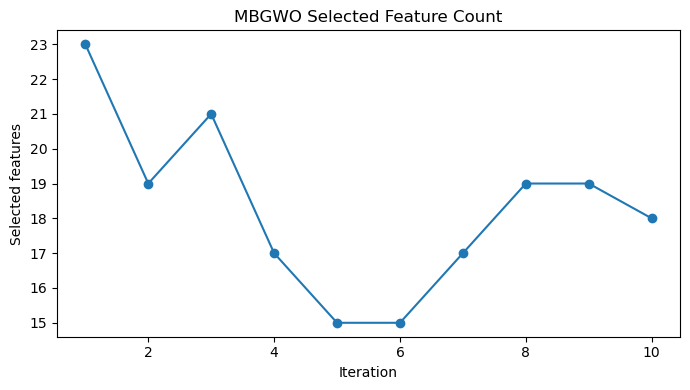

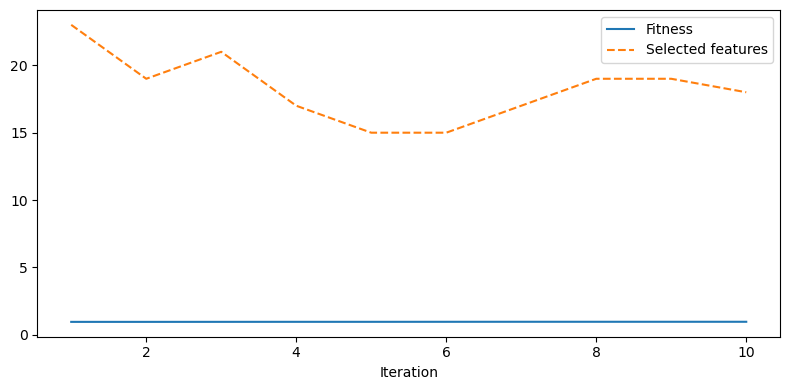

In [5]:
# CS_CCP_streamlit.py

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import streamlit as st
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

st.set_page_config(layout="wide", page_title="MBGWO IDS — Inference GUI")

ARTIFACTS_DEFAULT = "./artifacts"

# ---------- Cached loader ----------
@st.cache_resource(show_spinner=False)
def load_artifacts_cached(path):
    """Load models & preprocess artifacts. Returns dict + error string (if any)."""
    try:
        rf = joblib.load(os.path.join(path, "rf_model.joblib"))

        # svm optional
        svm = None
        try:
            svm = joblib.load(os.path.join(path, "svm_model.joblib"))
        except Exception:
            svm = None

        scaler = joblib.load(os.path.join(path, "scaler.joblib"))
        mask = np.load(os.path.join(path, "selected_mask.npy"))
        feature_names = joblib.load(os.path.join(path, "feature_names.joblib"))
        label_encoder = joblib.load(os.path.join(path, "label_encoder.joblib"))

        # history optional
        history = None
        hist_path = os.path.join(path, "mbgwo_history.csv")
        if os.path.exists(hist_path):
            history = pd.read_csv(hist_path)

        return {
            "rf": rf,
            "svm": svm,
            "scaler": scaler,
            "mask": mask,
            "feature_names": feature_names,
            "label_encoder": label_encoder,
            "history": history
        }, None

    except Exception as e:
        return None, str(e)


# ---------- Utility plotting ----------
def plot_confusion(cm, class_names):
    fig, ax = plt.subplots(figsize=(6,5))
    im = ax.imshow(cm, interpolation='nearest')
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    fig.colorbar(im, ax=ax)
    return fig


def plot_history(history_df):
    figs = {}
    try:
        iters = history_df["iter"].tolist()
        fitness = history_df["best_score"].tolist()
        feat_count = history_df["selected_count"].tolist()

        # fitness
        fig1, ax1 = plt.subplots(figsize=(7,4))
        ax1.plot(iters, fitness, marker="o")
        ax1.set_title("MBGWO Fitness Convergence Curve")
        ax1.set_xlabel("Iteration")
        ax1.set_ylabel("Best fitness score")
        fig1.tight_layout()
        figs["fitness"] = fig1

        # feature count
        fig2, ax2 = plt.subplots(figsize=(7,4))
        ax2.plot(iters, feat_count, marker="o")
        ax2.set_title("MBGWO Selected Feature Count")
        ax2.set_xlabel("Iteration")
        ax2.set_ylabel("Selected features")
        fig2.tight_layout()
        figs["feat_count"] = fig2

        # combined
        fig3, ax3 = plt.subplots(figsize=(8,4))
        ax3.plot(iters, fitness, label="Fitness")
        ax3.plot(iters, feat_count, label="Selected features", linestyle="--")
        ax3.set_xlabel("Iteration")
        ax3.legend()
        fig3.tight_layout()
        figs["combined"] = fig3

    except Exception:
        pass

    return figs


# ---------- Main UI ----------
def run_app(artifacts_folder=ARTIFACTS_DEFAULT):

    st.title("MBGWO IDS — Inference-only GUI")
    st.markdown(
        "Upload test CSVs (same features/order used in training) or input a single sample. "
        "This app **does not train** — it performs inference using saved models."
    )

    # Sidebar
    with st.sidebar:
        st.header("Settings & Artifacts")
        artifacts_path = st.text_input("Artifacts folder", value=artifacts_folder)
        st.write("Files required:")
        st.write("- rf_model.joblib\n- scaler.joblib\n- selected_mask.npy\n- feature_names.joblib\n- label_encoder.joblib")
        st.write("Optional: svm_model.joblib, mbgwo_history.csv")
        if st.button("(Re)load artifacts"):
            pass

    artifacts, err = load_artifacts_cached(artifacts_path)
    if artifacts is None:
        st.error(f"Failed to load artifacts: {err}")
        st.stop()

    rf = artifacts["rf"]
    scaler = artifacts["scaler"]
    mask = artifacts["mask"]
    feature_names = artifacts["feature_names"]
    label_encoder = artifacts["label_encoder"]
    history = artifacts["history"]

    st.sidebar.success(f"Artifacts loaded — model: {type(rf).__name__}")
    st.sidebar.write(f"Expected feature count: {len(feature_names)}")
    st.sidebar.write(f"Selected features: {int(mask.sum())}")

    # Helper
    def preprocess_select(X_full):
        X_scaled = scaler.transform(X_full)
        sel_idx = np.where(mask == 1)[0]
        return X_scaled[:, sel_idx], sel_idx

    # ======================================================
    # Option A — CSV batch inference
    # ======================================================

    st.header("Option A — Upload CSV (batch inference)")
    uploaded = st.file_uploader("Upload test CSV", type=["csv"])
    ground_truth_col = st.text_input("Name of ground-truth column (optional)", value="")

    if uploaded is not None:
        df = pd.read_csv(uploaded)
        st.write(f"Uploaded {df.shape[0]} rows × {df.shape[1]} columns")

        if ground_truth_col and ground_truth_col in df.columns:
            y_true_raw = df[ground_truth_col].values
            X_df = df.drop(columns=[ground_truth_col]).copy()
        else:
            y_true_raw = None
            X_df = df.copy()

        # reorder if names match
        if X_df.shape[1] != len(feature_names):
            common = [c for c in feature_names if c in X_df.columns]
            if len(common) == len(feature_names):
                st.info("Reordering columns to match training features.")
                X_df = X_df[feature_names]
            else:
                st.error("Column mismatch. Please upload aligned CSV.")
                st.stop()

        # convert
        try:
            X_raw = X_df.values.astype(float)
        except Exception as e:
            st.error(f"Feature conversion error: {e}")
            st.stop()

        X_sel, _ = preprocess_select(X_raw)

        # predictions
        try:
            probs = rf.predict_proba(X_sel)
            preds = rf.predict(X_sel)
            confidences = probs.max(axis=1)
        except Exception:
            preds = rf.predict(X_sel)
            confidences = np.full(len(preds), np.nan)

        preds_labels = label_encoder.inverse_transform(preds)

        # display preds
        st.subheader("Predictions (first 50 rows)")
        st.dataframe(
            pd.concat(
                [X_df.reset_index(drop=True).iloc[:50],
                 pd.DataFrame({"prediction": preds_labels[:50],
                               "confidence": confidences[:50]})],
                axis=1
            )
        )

        # accuracy if label provided
        if y_true_raw is not None:
            try:
                y_true_enc = label_encoder.transform(y_true_raw.astype(str))
                acc = accuracy_score(y_true_enc, preds)
                st.write(f"Accuracy: **{acc:.4%}**")

                cm = confusion_matrix(y_true_enc, preds)
                st.text(classification_report(y_true_enc, preds,
                                              zero_division=0,
                                              target_names=label_encoder.classes_))
                st.pyplot(plot_confusion(cm, label_encoder.classes_))

            except Exception:
                st.warning("Unable to decode ground-truth labels. Showing predictions only.")

    # ======================================================
    # Option B — Single sample inference + Accuracy
    # ======================================================

    st.header("Option B — Single Sample (Manual Input)")
    st.markdown("Now supports accuracy & confusion matrix when true label is provided.")

    single_mode = st.radio("Input mode:", ["Paste full CSV row", "Compact inputs"])

    if single_mode == "Paste full CSV row":
        row_text = st.text_area("Paste comma-separated values", height=120)
        true_label_text = st.text_input("Optional: Enter true label")

        if st.button("Predict pasted row"):
            if not row_text.strip():
                st.error("Paste a row first.")
            else:
                try:
                    vals = [float(x.strip()) for x in row_text.strip().split(",")]
                    if len(vals) != len(feature_names):
                        st.error(f"Expected {len(feature_names)} values.")
                    else:
                        X_raw = np.array(vals).reshape(1, -1)
                        X_sel, _ = preprocess_select(X_raw)

                        try:
                            p = rf.predict_proba(X_sel)
                            pred = rf.predict(X_sel)[0]
                            conf = p.max(axis=1)[0]
                        except Exception:
                            pred = rf.predict(X_sel)[0]
                            conf = np.nan

                        pred_label = label_encoder.inverse_transform([pred])[0]
                        st.success(f"Predicted: **{pred_label}**, confidence={conf:.3f}")

                        # ---- NEW: compute accuracy if true label provided ----
                        if true_label_text.strip():
                            try:
                                y_true_enc = label_encoder.transform([true_label_text.strip()])
                                acc = accuracy_score(y_true_enc, [pred])

                                st.write(f"Accuracy for this sample: **{acc:.2f}**")

                                cm = confusion_matrix(y_true_enc, [pred])
                                st.text(
                                    classification_report(
                                        y_true_enc, [pred],
                                        zero_division=0,
                                        target_names=label_encoder.classes_
                                    )
                                )
                                st.pyplot(plot_confusion(cm, label_encoder.classes_))

                            except Exception as e:
                                st.warning(f"Could not decode true label: {e}")

                except Exception as e:
                    st.error(f"Parse error: {e}")

    else:
        # compact mode
        sel_idx = np.where(mask == 1)[0]
        cols = [feature_names[i] for i in sel_idx]

        st.write("Enter selected feature values (others = 0).")

        with st.form("compact_form"):
            inputs = {c: st.number_input(c, value=0.0) for c in cols}
            true_label_text = st.text_input("Optional: Enter true label")
            submitted = st.form_submit_button("Predict compact")

        if submitted:
            full = np.zeros((1, len(feature_names)), dtype=float)
            for j, idxf in enumerate(sel_idx):
                full[0, idxf] = inputs[cols[j]]

            X_sel, _ = preprocess_select(full)

            try:
                p = rf.predict_proba(X_sel)
                pred = rf.predict(X_sel)[0]
                conf = p.max(axis=1)[0]
            except Exception:
                pred = rf.predict(X_sel)[0]
                conf = np.nan

            pred_label = label_encoder.inverse_transform([pred])[0]
            st.success(f"Predicted: **{pred_label}**, confidence={conf:.3f}")

            # ---- NEW: Accuracy + Confusion matrix ----
            if true_label_text.strip():
                try:
                    y_true_enc = label_encoder.transform([true_label_text.strip()])
                    acc = accuracy_score(y_true_enc, [pred])

                    st.write(f"Accuracy for this sample: **{acc:.2f}**")

                    cm = confusion_matrix(y_true_enc, [pred])
                    st.text(
                        classification_report(
                            y_true_enc, [pred],
                            zero_division=0,
                            target_names=label_encoder.classes_
                        )
                    )
                    st.pyplot(plot_confusion(cm, label_encoder.classes_))

                except Exception as e:
                    st.warning(f"Could not decode true label: {e}")

    # MBGWO history plots
    if history is not None:
        st.header("MBGWO Optimization History")
        figs = plot_history(history)
        for key in figs:
            st.pyplot(figs[key])

    st.markdown("---")
    st.caption("Ensure artifact files match training config. MBGWO objects must be redefined before joblib.load().")


if __name__ == "__main__":
    run_app()
